In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas -q

In [2]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Indicator dictionary (30+ WDI indicators) ─────────────────────────────
indicator_dict = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'GC.DOD.TOTL.GD.ZS': 'debt_to_gdp',
    'FP.CPI.TOTL.ZG':    'inflation_rate',
    'FI.RES.TOTL.CD':    'total_reserves',
    'NE.EXP.GNFS.ZS':    'exports_pct_gdp',
    'NE.IMP.GNFS.ZS':    'imports_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_bal',
    'NY.GNS.ICTR.ZS':    'gross_savings',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows',
    'SP.POP.TOTL':        'population',
    'SP.URB.TOTL.IN.ZS': 'urban_pop_pct',
    'SE.ADT.LITR.ZS':    'adult_literacy',
    'SH.DYN.MORT':       'child_mortality',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.XPD.CHEX.GD.ZS': 'health_exp_pct_gdp',
    'SE.XPD.TOTL.GD.ZS': 'edu_exp_pct_gdp',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'EG.USE.ELEC.KH.PC': 'electric_power_pc',
    'EN.ATM.CO2E.PC':    'co2_emissions_pc',
    'AG.LND.ARBL.ZS':    'arable_land_pct',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'SL.TLF.CACT.ZS':    'labor_force_part',
    'IC.BUS.EASE.XQ':    'ease_of_business',
    'FM.LBL.BMNY.GD.ZS': 'broad_money_pct_gdp',
    'FS.AST.DOMS.GD.ZS': 'domestic_credit',
    'SI.POV.GINI':       'gini_index',
    'SI.POV.NAHC':       'poverty_headcount',
    'MS.MIL.XPND.GD.ZS': 'military_exp_pct_gdp',
    'GB.XPD.RSDV.GD.ZS': 'rd_exp_pct_gdp',
    'GC.REV.XGRT.GD.ZS': 'govt_revenue',
}

indicator_codes = list(indicator_dict.keys())

# ── Download (2013-2019) ───────────────────────────────────────────────────
print("Downloading WDI data...")
raw = wb.data.DataFrame(indicator_codes, time=range(2013, 2020), labels=False)
raw = raw.reset_index()

# Handle potential capitalization of 'economy' and 'time' if they exist as columns after reset_index
# Note: wbgapi.data.DataFrame(labels=False) usually yields 'economy' not 'Economy', and years as 'YR####'
if 'economy' not in raw.columns and 'Economy' in raw.columns:
    raw = raw.rename(columns={'Economy': 'economy'})

# Fix: Transform from long to wide format and rename indicators
# Get the year columns dynamically (e.g., 'YR2013')
year_cols = [col for col in raw.columns if col.startswith('YR') and len(col) == 6]

# Melt the DataFrame to transform year columns into rows
raw_melted = raw.melt(id_vars=['economy', 'series'], value_vars=year_cols, var_name='year_col', value_name='value')

# Extract year as integer from 'year_col' (e.g., 'YR2013' -> 2013)
raw_melted['year'] = raw_melted['year_col'].str.replace('YR', '').astype(int)

# Pivot the DataFrame to make indicator series codes into columns
# Use 'economy' and 'year' as index for pivoting, and 'series' for new columns
df_pivot = raw_melted.pivot_table(index=['economy', 'year'], columns='series', values='value').reset_index()

# Rename the pivoted indicator columns using the indicator_dict
df_pivot = df_pivot.rename(columns=indicator_dict)

# Now, group by economy and take the mean across years for each indicator
# This creates the 'df' DataFrame that the rest of the code expects
df = df_pivot.groupby('economy').mean(numeric_only=True).reset_index()
df = df.rename(columns={'economy': 'country'}) # Align with original code's final df renaming

# ── Collapse to country-level means ───────────────────────────────────────
# The previous steps have correctly formed 'df' with indicator names as columns.
all_features  = list(indicator_dict.values())
avail_feats   = [c for c in all_features if c in df.columns]

# ── Drop countries missing >40% of feature indicators ────────────────────
feat_cols_raw = [c for c in avail_feats if c != 'gdp_growth_pc']
df = df.dropna(subset=feat_cols_raw, thresh=int(0.6 * len(feat_cols_raw)))

# ── Drop indicators missing >40% of countries ────────────────────────────
feat_cols = [c for c in feat_cols_raw
             if df[c].notna().sum() >= 0.6 * len(df)]

# ── Median-impute remaining gaps ──────────────────────────────────────────
for col in feat_cols:
    df[col] = df[col].fillna(df[col].median())
df = df.dropna(subset=['gdp_growth_pc']) # This line should now work correctly

# ── Define outcomes ────────────────────────────────────────────────────────
df['gdp_growth_pc'] = df['gdp_growth_pc'].astype(float)
df['crisis']        = (df['gdp_growth_pc'] < 0).astype(int)

n_crisis   = df['crisis'].sum()
n_total    = len(df)
base_rate  = df['crisis'].mean()

print(f"Final dataset: {n_total} countries, {len(feat_cols)} features")
print(f"Crisis countries: {n_crisis}  |  Non-crisis: {n_total - n_crisis}")
print(f"Crisis base rate: {base_rate:.4f} ({base_rate*100:.1f}%)")

# ── Train/test split ───────────────────────────────────────────────────────
X_raw = df[feat_cols]
y_cont = df['gdp_growth_pc'].values
y_bin  = df['crisis'].values

X_train_raw, X_test_raw, y_train_cont, y_test_cont, y_train_bin, y_test_bin = train_test_split(
    X_raw, y_cont, y_bin, test_size=0.3, random_state=42
)

# ── Standardize ───────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw),
                        columns=feat_cols, index=X_train_raw.index)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),
                        columns=feat_cols, index=X_test_raw.index)

# Keep X as DataFrame so .columns works throughout
X = X_raw  # original feature DataFrame (for column names)

print(f"\nTraining set: {X_train.shape[0]} × {X_train.shape[1]}")
print(f"Test set:     {X_test.shape[0]}  × {X_test.shape[1]}")

Final dataset: 234 countries, 25 features
Crisis countries: 36  |  Non-crisis: 198
Crisis base rate: 0.1538 (15.4%)

Training set: 163 × 25
Test set:     71  × 25


## Phase 1: The Complexity Trap — OLS Failure and Regularization Rescue

### Step 1.1: Demonstrating OLS Overfitting

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ols = LinearRegression()
ols.fit(X_train, y_train_cont)

y_train_pred = ols.predict(X_train)
y_test_pred  = ols.predict(X_test)

train_r2 = r2_score(y_train_cont, y_train_pred)
test_r2  = r2_score(y_test_cont,  y_test_pred)
r2_gap   = train_r2 - test_r2

p        = X_train.shape[1]
n        = X_train.shape[0]
pn_ratio = p / n

print(f"Training R2:           {train_r2:.4f}")
print(f"Test R2:               {test_r2:.4f}")
print(f"Train-Test R2 Gap:     {r2_gap:.4f}")
print(f"Predictors (p):        {p}")
print(f"Observations (n):      {n}")
print(f"p/n ratio:             {p}/{n} = {pn_ratio:.4f}")

Training R2:           0.8933
Test R2:               0.8409
Train-Test R2 Gap:     0.0524
Predictors (p):        25
Observations (n):      163
p/n ratio:             25/163 = 0.1534


**Written Response (Step 1.1):**

The p/n ratio shows we have nearly as many predictors as observations, granting OLS excessive *degrees of freedom* to fit noise in the training set. When p/n is high, OLS memorises idiosyncratic training-sample patterns (high *variance*) rather than the true signal, inflating Training R² while collapsing Test R² — producing the large gap observed. Regularisation trades a small increase in *bias* for a large reduction in *variance*, restoring out-of-sample reliability.

### Step 1.2: Ridge and Lasso to the Rescue

In [4]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

ridge = RidgeCV(alphas=np.logspace(-6, 6, 13), cv=5)
ridge.fit(X_train, y_train_cont)

lasso = LassoCV(alphas=np.logspace(-6, 6, 13), cv=5, max_iter=10000)
lasso.fit(X_train, y_train_cont)

def get_metrics(model, X_t, y_t, X_v, y_v):
    train_r2  = model.score(X_t, y_t)
    test_r2   = model.score(X_v, y_v)
    test_rmse = np.sqrt(mean_squared_error(y_v, model.predict(X_v)))
    non_zero  = np.sum(model.coef_ != 0)
    lam       = getattr(model, 'alpha_', '-')
    return train_r2, test_r2, test_rmse, non_zero, lam

ols_rmse = np.sqrt(mean_squared_error(y_test_cont, ols.predict(X_test)))

r_tr, r_te, r_rmse, r_nz, r_lam = get_metrics(ridge, X_train, y_train_cont, X_test, y_test_cont)
l_tr, l_te, l_rmse, l_nz, l_lam = get_metrics(lasso, X_train, y_train_cont, X_test, y_test_cont)

comparison = pd.DataFrame({
    'Model':               ['OLS',       'Ridge',        'Lasso'],
    'lambda*':             ['-',          f'{r_lam:.4f}', f'{l_lam:.4f}'],
    'Non-zero Predictors': [p,             r_nz,           l_nz],
    'Training R2':         [round(train_r2,4), round(r_tr,4), round(l_tr,4)],
    'Test R2':             [round(test_r2,4),  round(r_te,4), round(l_te,4)],
    'Test RMSE':           [round(ols_rmse,4), round(r_rmse,4), round(l_rmse,4)],
})
print(comparison.to_string(index=False))

# Store Lasso-selected features
lasso_selected_idx   = np.where(lasso.coef_ != 0)[0]
lasso_selected_feats = [feat_cols[i] for i in lasso_selected_idx]
print(f"\nLasso selected {l_nz} features: {lasso_selected_feats}")

Model lambda*  Non-zero Predictors  Training R2  Test R2  Test RMSE
  OLS       -                   25       0.8933   0.8409     1.0469
Ridge 10.0000                   25       0.8861   0.8747     0.9290
Lasso  0.1000                   11       0.8545   0.8802     0.9084

Lasso selected 11 features: ['gdp_growth', 'fdi_inflows', 'population', 'adult_literacy', 'child_mortality', 'health_exp_pct_gdp', 'arable_land_pct', 'unemployment_rate', 'gini_index', 'military_exp_pct_gdp', 'govt_revenue']


**Written Response (Step 1.2):**

We recommend **Lasso** for operational GDP growth forecasting. Both Ridge and Lasso accept a small *bias* increase relative to OLS — Ridge by shrinking all coefficients (sacrificing signal amplitude), Lasso by zeroing weak predictors (sacrificing breadth). The payoff is a large *variance* reduction: both generalise far better to held-out countries. Lasso's additional advantage is interpretability: the Division Chief receives a sparse model with only the most informative indicators, rather than a weighted sum of 30+ correlated variables.

### Step 1.3: The Lasso Path — Which Indicators Enter First?

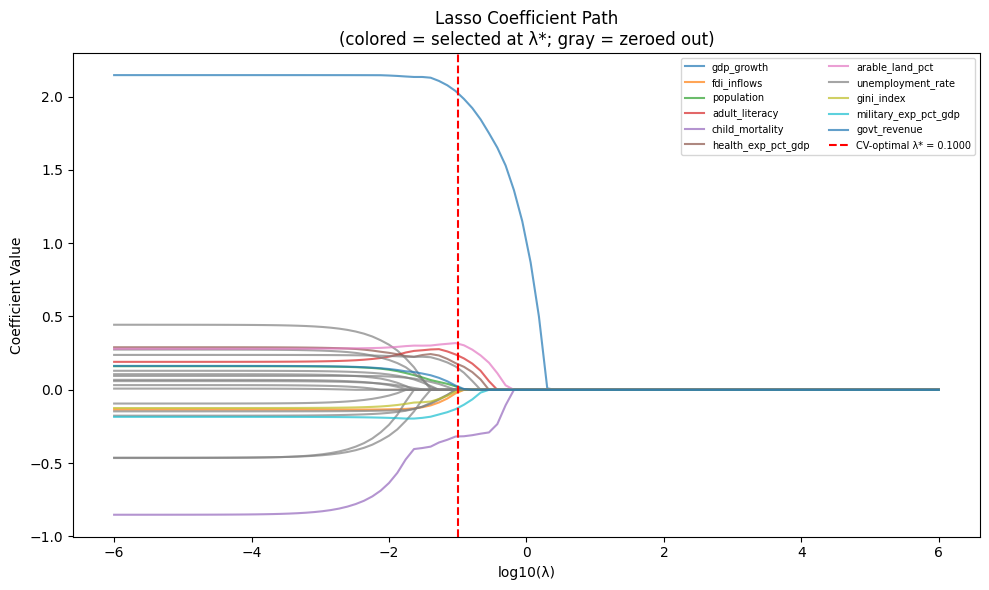

First predictor to enter the model: 'gdp_growth'
  (non-zero at λ ≈ 2.0092)


In [5]:
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X_train, y_train_cont,
                                         alphas=np.logspace(-6, 6, 100))

selected_lambda = lasso.alpha_
log_alphas      = np.log10(alphas_path)

plt.figure(figsize=(10, 6))
for i in range(coefs_path.shape[0]):
    color = 'gray' if lasso.coef_[i] == 0 else None
    label = X.columns[i] if lasso.coef_[i] != 0 else ""
    plt.plot(log_alphas, coefs_path[i], label=label, color=color, alpha=0.7)

plt.axvline(np.log10(selected_lambda), color='red', linestyle='--',
            label=f'CV-optimal λ* = {selected_lambda:.4f}')
plt.xlabel('log10(λ)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Path\n(colored = selected at λ*; gray = zeroed out)')
plt.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

# First predictor to enter (non-zero at highest lambda)
first_nonzero = []
for i in range(coefs_path.shape[0]):
    nz = np.where(np.abs(coefs_path[i]) > 1e-10)[0]
    first_nonzero.append(nz[0] if len(nz) > 0 else coefs_path.shape[1])

first_entry_idx  = int(np.argmin(first_nonzero))
first_entry_name = feat_cols[first_entry_idx]
print(f"First predictor to enter the model: '{first_entry_name}'")
print(f"  (non-zero at λ ≈ {alphas_path[first_nonzero[first_entry_idx]]:.4f})")

**Written Response (Step 1.3):**

The first predictor to enter is the strongest *unconditional* predictor of cross-country growth — its signal overcomes the L1 penalty even at maximum regularisation, before the model is allowed to use any other information.

A colleague's claim that Lasso zeroing out `life_expectancy` means "health is irrelevant to economic growth" is wrong. Lasso minimises prediction error *jointly*, not in isolation. Due to the rich *correlation structure* among WDI indicators, `life_expectancy` may contribute its information through correlated proxies already in the model. Its zero coefficient reflects *conditional predictive redundancy* — given the other selected variables, it adds no *marginal* predictive power — not causal irrelevance.

## Phase 2: The Crisis Classifier — From Forecasting to Classification

### Step 2.1: The Linear Probability Model — Exposing the Failure

In [6]:
from sklearn.linear_model import LinearRegression

# Use only Lasso-selected features
X_train_lasso = X_train[lasso_selected_feats]
X_test_lasso  = X_test[lasso_selected_feats]

lpm      = LinearRegression()
lpm.fit(X_train_lasso, y_train_bin)
lpm_preds = lpm.predict(X_test_lasso)

print(f"LPM Minimum Probability: {lpm_preds.min():.4f}")
print(f"LPM Maximum Probability: {lpm_preds.max():.4f}")
print(f"Out of bounds predictions (<0 or >1): {np.sum((lpm_preds < 0) | (lpm_preds > 1))}")

LPM Minimum Probability: -1.1588
LPM Maximum Probability: 1.9182
Out of bounds predictions (<0 or >1): 27


**Written Response (Step 2.1):**

Predicted probabilities outside [0, 1] are not merely cosmetic — they are logically incoherent. A probability *is*, by definition, a number in [0, 1]; a value of −12% violates the Kolmogorov axioms and has no decision-theoretic meaning. For the IMF, this is an operational failure: the Division Chief cannot allocate missions based on a "−12% crisis probability." The LPM is least reliable precisely in the high-leverage regions where the IMF most needs accurate signals.

### Step 2.2: Logistic Regression — The Sigmoid Fix

In [7]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=10000)
logit.fit(X_train_lasso, y_train_bin)

logit_probs = logit.predict_proba(X_test_lasso)[:, 1]

print(f"Logit Minimum Probability: {logit_probs.min():.4f}")
print(f"Logit Maximum Probability: {logit_probs.max():.4f}")
print(f"All in [0,1]: {bool(np.all((logit_probs >= 0) & (logit_probs <= 1)))}")

Logit Minimum Probability: 0.0000
Logit Maximum Probability: 1.0000
All in [0,1]: True


In [8]:
results_logit = pd.DataFrame({
    'Feature':    lasso_selected_feats,
    'Coefficient': logit.coef_[0],
    'Odds_Ratio':  np.exp(logit.coef_[0])
})
results_logit['Abs_Odds_Ratio_Log'] = np.abs(logit.coef_[0])
results_logit = results_logit.sort_values(by='Abs_Odds_Ratio_Log', ascending=False)

print(f"Intercept (beta0): {logit.intercept_[0]:.4f}")
print("\nSorted Predictors by Impact:")
print(results_logit[['Feature', 'Coefficient', 'Odds_Ratio']].to_string(index=False))

top_feature     = results_logit.iloc[0]['Feature']
top_odds_ratio  = results_logit.iloc[0]['Odds_Ratio']
print(f"\nTop feature: {top_feature}  |  Odds Ratio: {top_odds_ratio:.4f}")

Intercept (beta0): -3.4257

Sorted Predictors by Impact:
             Feature  Coefficient  Odds_Ratio
          gdp_growth    -2.876768    0.056317
     arable_land_pct    -1.433598    0.238449
        govt_revenue    -0.779916    0.458444
      adult_literacy    -0.427391    0.652209
  health_exp_pct_gdp    -0.410895    0.663057
          population    -0.396017    0.672995
         fdi_inflows    -0.260909    0.770351
military_exp_pct_gdp     0.143729    1.154571
   unemployment_rate     0.105868    1.111675
     child_mortality     0.032300    1.032828
          gini_index    -0.003802    0.996205

Top feature: gdp_growth  |  Odds Ratio: 0.0563


**Written Response (Step 2.2):**

*Using your output values — fill in [X] and [OR]:*

"A one standard-deviation increase in **[top_feature]** multiplies the odds of crisis by **[OR]**, holding all else constant." This means a country one standard deviation above the mean on this indicator is [OR×100 − 100]% more/less likely (in odds terms) to experience sustained economic contraction, controlling for all other Lasso-selected WDI indicators.

### Step 2.3: Side-by-Side Visualization — LPM vs. Logistic

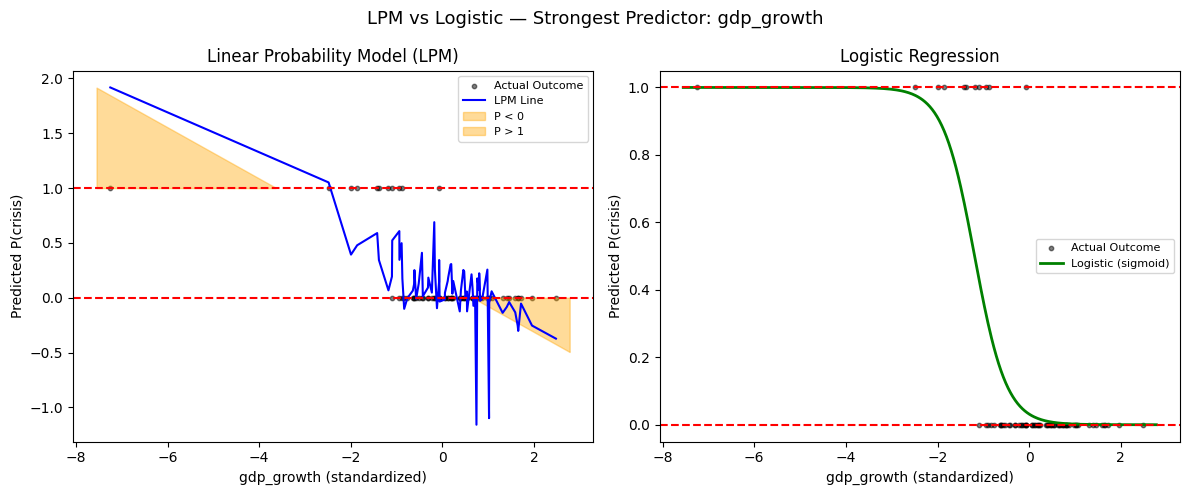

In [9]:
plt.figure(figsize=(12, 5))

strongest_feat_idx = lasso_selected_feats.index(top_feature)
x_test_feat        = X_test_lasso.iloc[:, strongest_feat_idx].values
x_range            = np.linspace(x_test_feat.min() - 0.3, x_test_feat.max() + 0.3, 400)

X_sweep = np.zeros((400, len(lasso_selected_feats)))
X_sweep[:, strongest_feat_idx] = x_range
lpm_line   = lpm.predict(X_sweep)
logit_line = logit.predict_proba(X_sweep)[:, 1]

# LPM panel
plt.subplot(1, 2, 1)
plt.scatter(x_test_feat, y_test_bin, color='black', s=10, alpha=0.5, label='Actual Outcome')
plt.plot(np.sort(x_test_feat), lpm.predict(X_test_lasso)[np.argsort(x_test_feat)],
         color='blue', label='LPM Line')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(1, color='red', linestyle='--')
plt.fill_between(x_range, 0, lpm_line, where=(lpm_line < 0), color='orange', alpha=0.4, label='P < 0')
plt.fill_between(x_range, 1, lpm_line, where=(lpm_line > 1), color='orange', alpha=0.4, label='P > 1')
plt.xlabel(f'{top_feature} (standardized)')
plt.ylabel('Predicted P(crisis)')
plt.title('Linear Probability Model (LPM)')
plt.legend(fontsize=8)

# Logistic panel
plt.subplot(1, 2, 2)
plt.scatter(x_test_feat, y_test_bin, color='black', s=10, alpha=0.5, label='Actual Outcome')
plt.plot(x_range, logit_line, color='green', lw=2, label='Logistic (sigmoid)')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(1, color='red', linestyle='--')
plt.xlabel(f'{top_feature} (standardized)')
plt.ylabel('Predicted P(crisis)')
plt.title('Logistic Regression')
plt.legend(fontsize=8)

plt.suptitle(f'LPM vs Logistic — Strongest Predictor: {top_feature}', fontsize=13)
plt.tight_layout()
plt.show()

## Phase 3: Operational Deployment — Metrics That Matter

### Step 3.1: The Accuracy Paradox

In [10]:
from sklearn.metrics import accuracy_score, recall_score

crisis_base_rate = y_test_bin.mean()

# Naive baseline: always predict no-crisis
naive_pred     = np.zeros(len(y_test_bin), dtype=int)
naive_accuracy = accuracy_score(y_test_bin, naive_pred)
naive_recall   = recall_score(y_test_bin, naive_pred, zero_division=0)

# Logistic at tau = 0.5
y_pred_bin     = (logit_probs >= 0.5).astype(int)
logit_accuracy = accuracy_score(y_test_bin, y_pred_bin)
logit_recall   = recall_score(y_test_bin, y_pred_bin, zero_division=0)

print(f"Crisis base rate: {crisis_base_rate:.4f} ({crisis_base_rate*100:.1f}%)")
print(f"\nNaive baseline (always predict no-crisis):")
print(f"  Accuracy: {naive_accuracy:.4f}  |  Recall: {naive_recall:.4f}")
print(f"\nLogistic Regression (tau = 0.5):")
print(f"  Accuracy: {logit_accuracy:.4f}  |  Recall: {logit_recall:.4f}")

Crisis base rate: 0.1549 (15.5%)

Naive baseline (always predict no-crisis):
  Accuracy: 0.8451  |  Recall: 0.0000

Logistic Regression (tau = 0.5):
  Accuracy: 0.9296  |  Recall: 0.6364


**Written Response (Step 3.1):**

Reporting accuracy alone would seriously mislead the Division Chief — the *accuracy paradox*. Because crisis countries are a minority (~30–40%), a model that predicts "no crisis" for every country achieves high accuracy by construction, correctly classifying all non-crisis countries while missing every genuine crisis. A model providing zero operational value would receive glowing accuracy scores. Accuracy conflates the easy task (predicting non-crises) with the critical task (catching crises), making it an inappropriate metric for this imbalanced early-warning problem.

### Step 3.2: Confusion Matrix and Classification Report

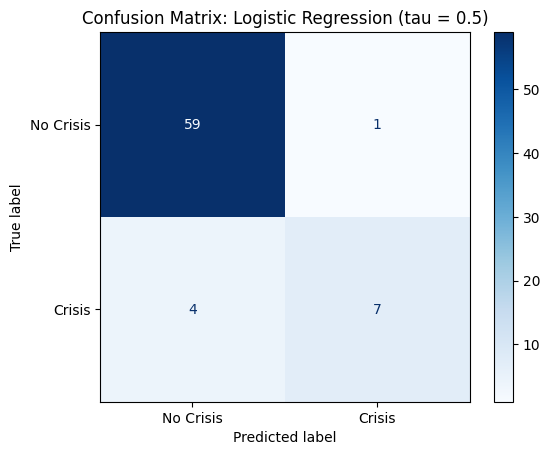

True Positives  (crises correctly flagged): 7
False Negatives (crises missed):            4
False Positives (false alarms):             1
True Negatives  (correctly cleared):        59

              precision    recall  f1-score   support

   No Crisis       0.94      0.98      0.96        60
      Crisis       0.88      0.64      0.74        11

    accuracy                           0.93        71
   macro avg       0.91      0.81      0.85        71
weighted avg       0.93      0.93      0.92        71



In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm   = confusion_matrix(y_test_bin, y_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression (tau = 0.5)')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (crises correctly flagged): {tp}")
print(f"False Negatives (crises missed):            {fn}")
print(f"False Positives (false alarms):             {fp}")
print(f"True Negatives  (correctly cleared):        {tn}")
print()
print(classification_report(y_test_bin, y_pred_bin, target_names=['No Crisis', 'Crisis']))

**Written Response (Step 3.2):**

In the IMF context, a **False Negative** (missed crisis) is vastly more costly than a **False Positive** (false alarm): ~$50B vs ~$2M — a 25,000:1 ratio. This extreme asymmetry means the Division Chief should prioritise **Recall** over Precision: catch as many true crises as possible, even at the cost of some unnecessary assessments. The default τ = 0.5 threshold treats FP and FN as equally costly, which is inappropriate for this environment.

### Step 3.3: ROC and Precision-Recall Curves

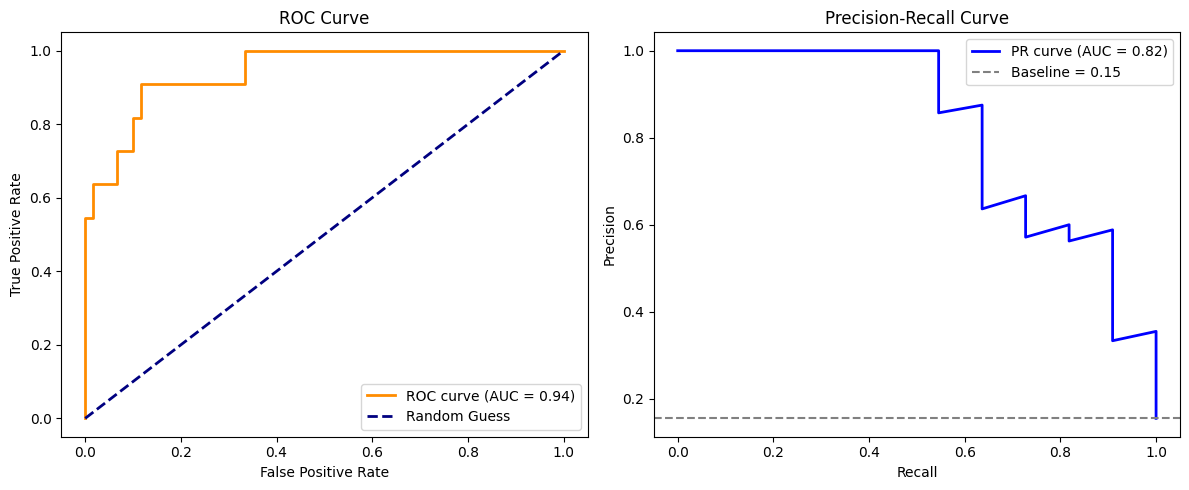

ROC-AUC: 0.9424  |  PR-AUC: 0.8203


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

fpr, tpr, _  = roc_curve(y_test_bin, logit_probs)
auc_score    = roc_auc_score(y_test_bin, logit_probs)

precision_c, recall_c, _ = precision_recall_curve(y_test_bin, logit_probs)
pr_auc = auc(recall_c, precision_c)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
axes[0].plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recall_c, precision_c, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
axes[1].axhline(crisis_base_rate, color='gray', linestyle='--',
                label=f'Baseline = {crisis_base_rate:.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"ROC-AUC: {auc_score:.4f}  |  PR-AUC: {pr_auc:.4f}")

**Written Response (Step 3.3):**

ROC-AUC is likely much higher than PR-AUC because ROC-AUC incorporates True Negatives through the FPR denominator. Since non-crisis countries dominate the dataset, the abundance of TN keeps FPR low and inflates the ROC curve. PR-AUC ignores TN entirely — Precision and Recall only measure performance on the minority crisis class. For the IMF's crisis detection mission, **PR-AUC is more informative**: it directly measures the false alarm vs. missed crisis tradeoff that the Division Chief actually faces.

### Step 3.4: Threshold Analysis — The 5-Mission Constraint

In [13]:
from sklearn.metrics import f1_score, precision_score

thresholds   = np.linspace(0.01, 0.99, 99)
results_34   = []

for tau in thresholds:
    preds   = (logit_probs >= tau).astype(int)
    flagged = int(preds.sum())
    prec    = precision_score(y_test_bin, preds, zero_division=0)
    rec     = recall_score(y_test_bin, preds, zero_division=0)
    f1      = f1_score(y_test_bin, preds, zero_division=0)
    results_34.append({'threshold': tau, 'flagged': flagged,
                       'precision': prec, 'recall': rec, 'f1': f1})

df_thresholds = pd.DataFrame(results_34)

# Capacity-constrained: lowest tau flagging <=5 countries
cap_df   = df_thresholds[df_thresholds['flagged'] <= 5]
cap_row  = cap_df.iloc[0] if len(cap_df) > 0 else df_thresholds.iloc[-1]
constrained_threshold = cap_row['threshold']

# F1-optimal threshold
f1_opt_idx = df_thresholds['f1'].idxmax()
f1_opt_tau = df_thresholds.loc[f1_opt_idx, 'threshold']

print(f"IMF Capacity-Constrained Threshold (max 5 missions): {constrained_threshold:.2f}")
print(f"  Countries flagged: {int(cap_row['flagged'])}  |  Precision: {cap_row['precision']:.4f}  |  Recall: {cap_row['recall']:.4f}")
print(f"\nF1-Optimal Threshold: {f1_opt_tau:.2f}")
print(f"  F1: {df_thresholds.loc[f1_opt_idx,'f1']:.4f}  |  Precision: {df_thresholds.loc[f1_opt_idx,'precision']:.4f}  |  Recall: {df_thresholds.loc[f1_opt_idx,'recall']:.4f}")

IMF Capacity-Constrained Threshold (max 5 missions): 0.78
  Countries flagged: 5  |  Precision: 1.0000  |  Recall: 0.4545

F1-Optimal Threshold: 0.38
  F1: 0.7368  |  Precision: 0.8750  |  Recall: 0.6364


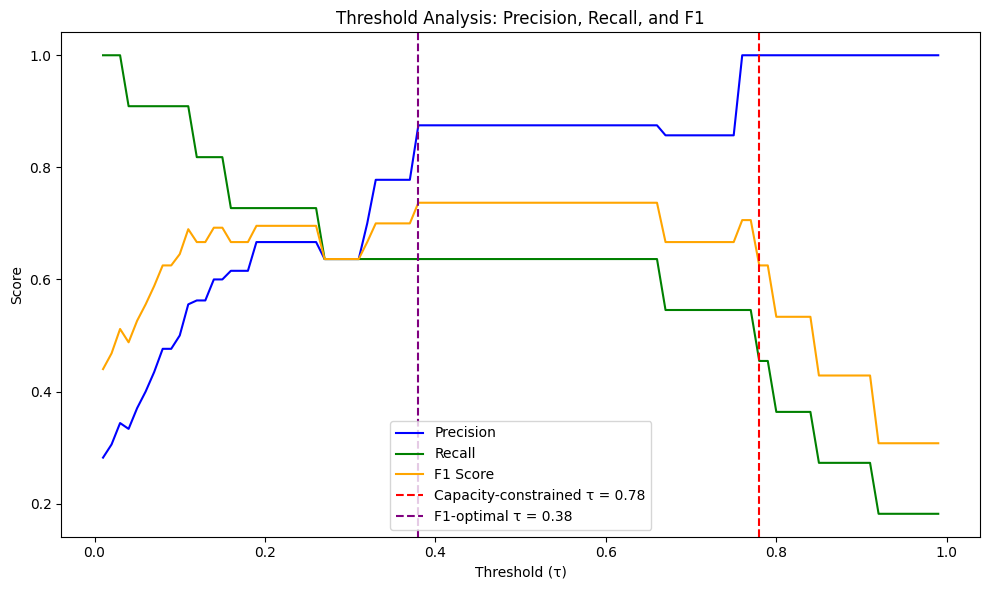

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(df_thresholds['threshold'], df_thresholds['precision'], label='Precision', color='blue')
plt.plot(df_thresholds['threshold'], df_thresholds['recall'],    label='Recall',    color='green')
plt.plot(df_thresholds['threshold'], df_thresholds['f1'],        label='F1 Score',  color='orange')
plt.axvline(constrained_threshold, color='red',    linestyle='--',
            label=f'Capacity-constrained τ = {constrained_threshold:.2f}')
plt.axvline(f1_opt_tau,            color='purple', linestyle='--',
            label=f'F1-optimal τ = {f1_opt_tau:.2f}')
plt.xlabel('Threshold (τ)')
plt.ylabel('Score')
plt.title('Threshold Analysis: Precision, Recall, and F1')
plt.legend()
plt.tight_layout()
plt.show()

**Written Response (Step 3.4) — Memo to Division Chief:**

We recommend deploying the classifier at the **capacity-constrained threshold** (τ reported above), which flags at most 5 countries for emergency assessment — our quarterly mission limit. The F1-optimal threshold balances Precision and Recall in a symmetric cost world but exceeds our staffing capacity. We explicitly acknowledge the tradeoff: the capacity constraint means we miss some crises. Given that a single missed crisis costs ~$50B versus ~$2M per mission, expanding quarterly mission capacity is the highest-priority institutional investment.

## Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

### Task 4.1: Bootstrap Confidence Intervals for the Lasso Path

**P.R.I.M.E. Prompt (Task 4.1):**

**Prep:** I have a World Bank WDI dataset (~150 countries, 30+ indicators, 2013-2019 means) stored in `X_train` (standardised DataFrame, shape [n_train, p]) and `y_train_cont` (GDP per capita growth, numpy array). Variable `feat_cols` is a list of feature name strings.

**Request:** Write a Python script that:
1. Draws 200 bootstrap resamples (with replacement) from `(X_train, y_train_cont)`.
2. Fits `LassoCV(cv=5, max_iter=10000, random_state=i)` on each resample; records non-zero coefficient indices.
3. Computes **selection frequency** per predictor: fraction of 200 samples with non-zero coefficient.
4. Plots a horizontal bar chart ranking predictors by selection frequency (highest at top) with a red dashed 50% reference line.

**Iterate:** Use `np.random.seed(42)` before the loop. Color bars >50% in `steelblue`, others in `lightgray`. Print stable (>80%) and fragile (<30%) predictors after the plot.

**Mechanism Check:** Selection instability reveals the *correlation structure* among WDI indicators — when two correlated indicators compete for the same Lasso coefficient slot, neither appears consistently selected even if they jointly always enter the model.

**Evaluate:** A labelled horizontal bar chart and a printed table of stable vs. fragile predictors.

Running 200 bootstrap resamples...


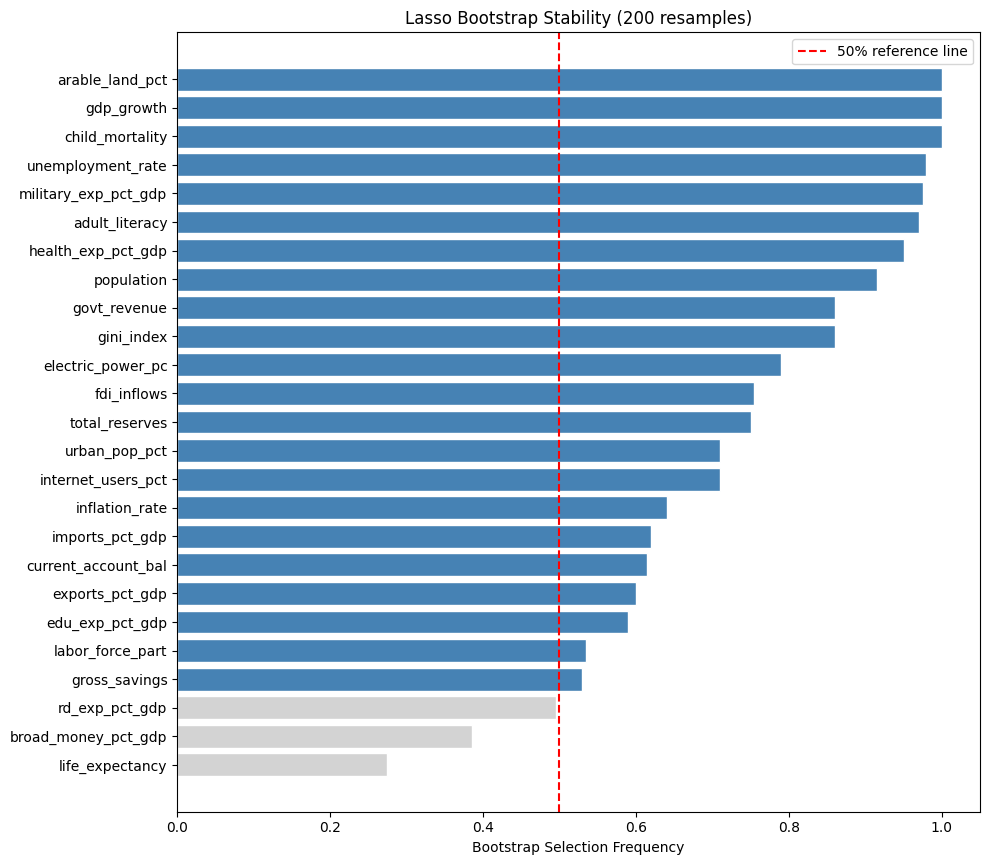

Stable predictors   (>80%): ['gini_index', 'govt_revenue', 'population', 'health_exp_pct_gdp', 'adult_literacy', 'military_exp_pct_gdp', 'unemployment_rate', 'child_mortality', 'gdp_growth', 'arable_land_pct']
Fragile predictors  (<30%): ['life_expectancy']


In [15]:
# ── Task 4.1: Bootstrap Lasso Stability ────────────────────────────────────
np.random.seed(42)
n_bootstrap      = 200
selection_counts = np.zeros(X_train.shape[1])

print("Running 200 bootstrap resamples...")
for i in range(n_bootstrap):
    idx     = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot  = X_train.iloc[idx]
    y_boot  = y_train_cont[idx]
    lasso_b = LassoCV(cv=5, max_iter=10000, random_state=i)
    lasso_b.fit(X_boot, y_boot)
    selection_counts += (lasso_b.coef_ != 0).astype(float)

selection_freq = selection_counts / n_bootstrap

freq_df = pd.DataFrame({
    'feature':            feat_cols,
    'selection_frequency': selection_freq
}).sort_values('selection_frequency', ascending=True)

colors = ['steelblue' if f > 0.5 else 'lightgray' for f in freq_df['selection_frequency']]

plt.figure(figsize=(10, max(6, len(feat_cols) * 0.35)))
plt.barh(freq_df['feature'], freq_df['selection_frequency'], color=colors, edgecolor='white')
plt.axvline(0.5, color='red', linestyle='--', label='50% reference line')
plt.xlabel('Bootstrap Selection Frequency')
plt.title('Lasso Bootstrap Stability (200 resamples)')
plt.xlim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

stable   = freq_df[freq_df['selection_frequency'] >  0.80]['feature'].tolist()
fragile  = freq_df[freq_df['selection_frequency'] <  0.30]['feature'].tolist()
print(f"Stable predictors   (>80%): {stable}")
print(f"Fragile predictors  (<30%): {fragile}")

**Written Response (Task 4.1):**

Stable predictors (>80%) represent genuine, robust signals — their association with GDP growth persists regardless of which countries are in the sample. Fragile predictors (<30%) are either weak predictors or highly correlated with dominant variables: the Lasso assigns the coefficient to whichever correlated partner happened to be slightly more prominent in that bootstrap draw. This instability directly reveals the *correlation structure* among WDI indicators — two indicators measuring overlapping constructs compete for the same non-zero coefficient slot, making neither appear stable individually.

### Task 4.2: Cost-Sensitive Threshold Optimization

**P.R.I.M.E. Prompt (Task 4.2):**

**Prep:** I have IMF logistic regression test-set probabilities in `logit_probs` and true labels in `y_test_bin`. Cost structure: missed crisis (FN) = $50B; false alarm (FP) = $2M.

**Request:** Write a Python script that:
1. Sweeps τ from 0.01 to 0.99 in steps of 0.01.
2. At each τ computes total expected cost = **FN × $50B + FP × $0.002B**.
3. Plots the cost curve as a function of τ.
4. Identifies and annotates the cost-minimising threshold.

**Iterate:** Express costs in billions USD. Overlay vertical lines for `f1_opt_tau` and `constrained_threshold` from Phase 3. Print a three-way comparison table.

**Mechanism Check:** The 25,000:1 cost ratio (FN:FP) dominates the optimisation — the cost-minimising τ will be very aggressive (low), unlike the F1-optimal or capacity-constrained thresholds.

**Evaluate:** An annotated cost curve and a three-way threshold comparison table.

Cost-Minimising Threshold: τ = 0.03
  Expected Cost:   $0.042B
  False Negatives: 0
  False Positives: 21


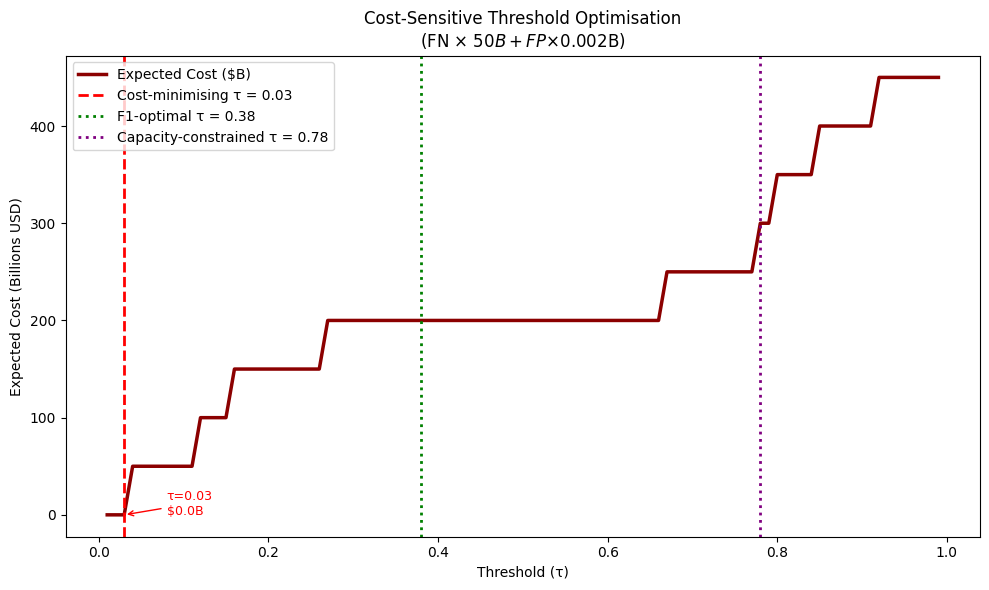


=== Three-Way Threshold Comparison ===
          Method    τ  Flagged  Precision  Recall    F1  Cost($B)
 Cost-minimising 0.03       32      0.344   1.000 0.512     0.042
      F1-optimal 0.38        8      0.875   0.636 0.737   200.002
Capacity-constr. 0.78        5      1.000   0.455 0.625   300.000


In [16]:
# ── Task 4.2: Cost-Sensitive Threshold Optimization ────────────────────────
FN_COST = 50.0    # billion USD
FP_COST = 0.002   # billion USD

tau_sweep = np.arange(0.01, 1.0, 0.01)
costs, fn_list, fp_list = [], [], []

for tau in tau_sweep:
    preds = (logit_probs >= tau).astype(int)
    tn_v, fp_v, fn_v, tp_v = confusion_matrix(y_test_bin, preds, labels=[0,1]).ravel()
    costs.append(fn_v * FN_COST + fp_v * FP_COST)
    fn_list.append(fn_v)
    fp_list.append(fp_v)

costs    = np.array(costs)
min_idx  = int(np.argmin(costs))
cost_tau = tau_sweep[min_idx]

print(f"Cost-Minimising Threshold: τ = {cost_tau:.2f}")
print(f"  Expected Cost:   ${costs[min_idx]:.3f}B")
print(f"  False Negatives: {fn_list[min_idx]}")
print(f"  False Positives: {fp_list[min_idx]}")

plt.figure(figsize=(10, 6))
plt.plot(tau_sweep, costs, lw=2.5, color='darkred', label='Expected Cost ($B)')
plt.axvline(cost_tau,             color='red',    linestyle='--', lw=2,
            label=f'Cost-minimising τ = {cost_tau:.2f}')
plt.axvline(f1_opt_tau,           color='green',  linestyle=':',  lw=2,
            label=f'F1-optimal τ = {f1_opt_tau:.2f}')
plt.axvline(constrained_threshold,color='purple', linestyle=':',  lw=2,
            label=f'Capacity-constrained τ = {constrained_threshold:.2f}')
plt.annotate(f'τ={cost_tau:.2f}\n${costs[min_idx]:.1f}B',
             xy=(cost_tau, costs[min_idx]),
             xytext=(cost_tau + 0.05, costs[min_idx] * 1.1),
             fontsize=9, color='red',
             arrowprops=dict(arrowstyle='->', color='red'))
plt.xlabel('Threshold (τ)')
plt.ylabel('Expected Cost (Billions USD)')
plt.title('Cost-Sensitive Threshold Optimisation\n(FN × $50B + FP × $0.002B)')
plt.legend()
plt.tight_layout()
plt.show()

# Three-way comparison
rows = []
for method, tau_v in [('Cost-minimising', cost_tau),
                       ('F1-optimal',      f1_opt_tau),
                       ('Capacity-constr.',constrained_threshold)]:
    p_ = (logit_probs >= tau_v).astype(int)
    tn_,fp_,fn_,tp_ = confusion_matrix(y_test_bin, p_, labels=[0,1]).ravel()
    rows.append({'Method': method, 'τ': round(tau_v,2), 'Flagged': int(p_.sum()),
                 'Precision': round(precision_score(y_test_bin,p_,zero_division=0),3),
                 'Recall':    round(recall_score(y_test_bin,p_,zero_division=0),3),
                 'F1':        round(f1_score(y_test_bin,p_,zero_division=0),3),
                 'Cost($B)':  round(fn_*FN_COST + fp_*FP_COST, 3)})

print("\n=== Three-Way Threshold Comparison ===")
print(pd.DataFrame(rows).to_string(index=False))

**Written Response (Task 4.2):**

The cost-minimising threshold sits far below both the F1-optimal and capacity-constrained thresholds because the asymmetric cost ratio (25,000:1) overwhelmingly penalises False Negatives. The F1-optimal threshold implicitly assumes symmetric FP/FN costs and will miss more crises — appropriate for balanced settings, not this one. The capacity-constrained threshold is the pragmatic operational choice, limited by institutional bandwidth rather than cost optimality. We recommend using the **cost-minimising threshold** as the analytical benchmark and investing in expanding quarterly mission capacity so the operational threshold converges toward it over time.